# Exploratory Data Analysis
**Date:** May 20, 2026

This notebook performs a comprehensive exploratory data analysis on the collected NSE stock data for RELIANCE, TCS, INFY, HDFCBANK, and ICICIBANK (2015–2026). The goal is to understand price behaviour, return distributions, inter-stock correlations, and key technical patterns before building predictive models.

## STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10
print('Libraries imported successfully.')

Libraries imported successfully.


## STEP 2 — Load All Stock Datasets

In [2]:
STOCKS = ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'ICICIBANK']
COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

dfs = {}
for stock in STOCKS:
    df = pd.read_csv(f'stock_datasets/{stock}.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    dfs[stock] = df
    print(f'{stock:12s} — {len(df):,} rows  |            {df["Date"].min().date()} to {df["Date"].max().date()}')

print('\nAll datasets loaded.')

RELIANCE     — 2,786 rows  |            2015-01-01 to 2026-04-16
TCS          — 2,786 rows  |            2015-01-01 to 2026-04-16
INFY         — 2,786 rows  |            2015-01-01 to 2026-04-16
HDFCBANK     — 2,786 rows  |            2015-01-01 to 2026-04-16
ICICIBANK    — 2,786 rows  |            2015-01-01 to 2026-04-16

All datasets loaded.


## STEP 3 — Basic Statistics Summary

In [3]:
print('=== Close Price Statistics (INR) ===')
summary = pd.DataFrame({
    stock: dfs[stock]['Close'].describe()
    for stock in STOCKS
}).round(2)
print(summary)

print('\n=== Missing Values Check ===')
for stock in STOCKS:
    missing = dfs[stock].isnull().sum().sum()
    print(f'{stock:12s} — missing values: {missing}')

=== Close Price Statistics (INR) ===
       RELIANCE      TCS     INFY  HDFCBANK  ICICIBANK
count   2786.00  2786.00  2786.00   2786.00    2786.00
mean     806.14  2239.30   960.52    586.81     627.34
std      448.69  1022.55   501.39    224.30     394.97
min      173.49   844.12   346.07    215.00     155.36
25%      393.31  1071.99   452.36    420.80     281.26
50%      876.31  1993.83   830.79    593.28     484.73
75%     1193.80  3127.54  1422.95    765.91     915.46
max     1592.30  4311.59  1942.22   1012.90    1477.20

=== Missing Values Check ===
RELIANCE     — missing values: 0
TCS          — missing values: 0
INFY         — missing values: 0
HDFCBANK     — missing values: 0
ICICIBANK    — missing values: 0


## STEP 4 — Price Trend: All 5 Stocks (2015–2026)

Normalised to base 100 at the start date so all stocks are comparable regardless of their absolute price levels.

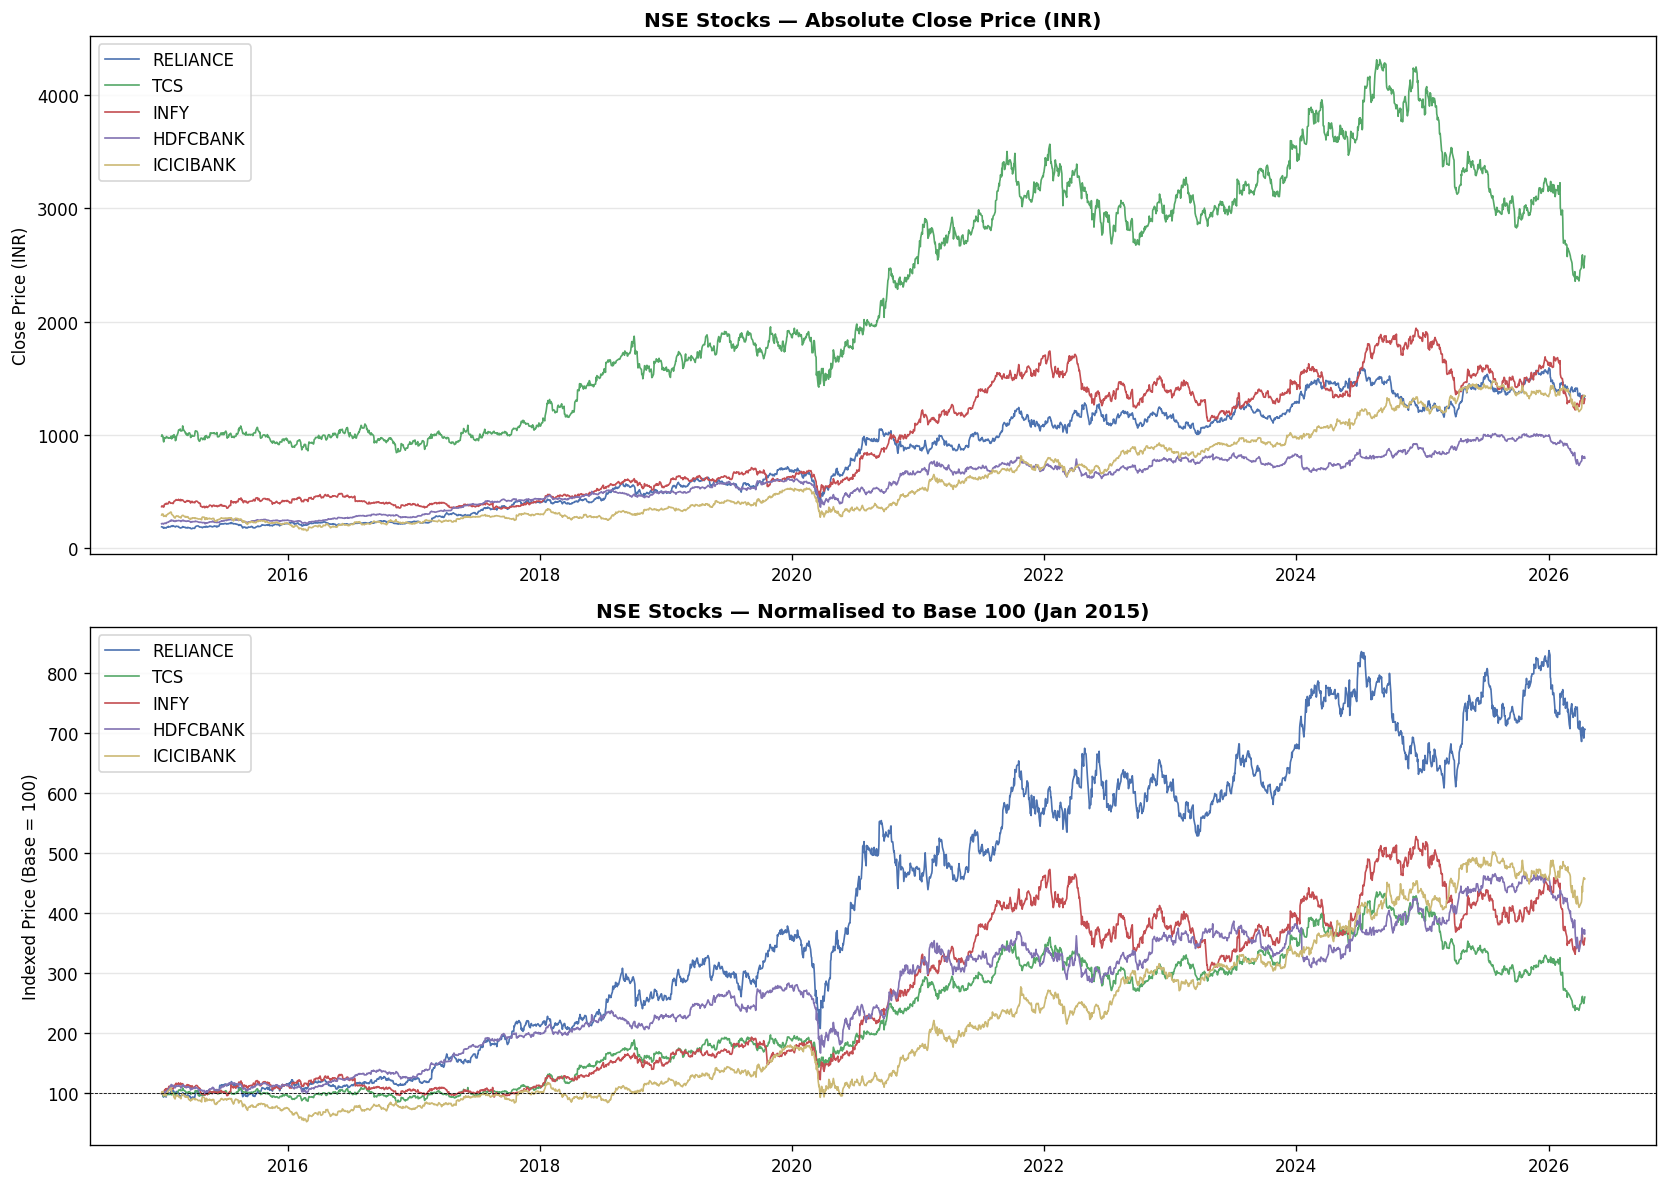

Price trend chart saved.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: absolute close prices
for stock, color in zip(STOCKS, COLORS):
    df = dfs[stock]
    axes[0].plot(df['Date'], df['Close'], label=stock, color=color, linewidth=1)
axes[0].set_title('NSE Stocks — Absolute Close Price (INR)', fontweight='bold')
axes[0].set_ylabel('Close Price (INR)')
axes[0].legend(loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(axis='y', alpha=0.3)

# Bottom: normalised to 100
for stock, color in zip(STOCKS, COLORS):
    df  = dfs[stock]
    norm = (df['Close'] / df['Close'].iloc[0]) * 100
    axes[1].plot(df['Date'], norm, label=stock, color=color, linewidth=1)
axes[1].axhline(100, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('NSE Stocks — Normalised to Base 100 (Jan 2015)', fontweight='bold')
axes[1].set_ylabel('Indexed Price (Base = 100)')
axes[1].legend(loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Price trend chart saved.')

## STEP 5 — RELIANCE: Price and Volume Analysis

RELIANCE is the primary stock used for modelling. This section examines its full price history alongside trading volume.

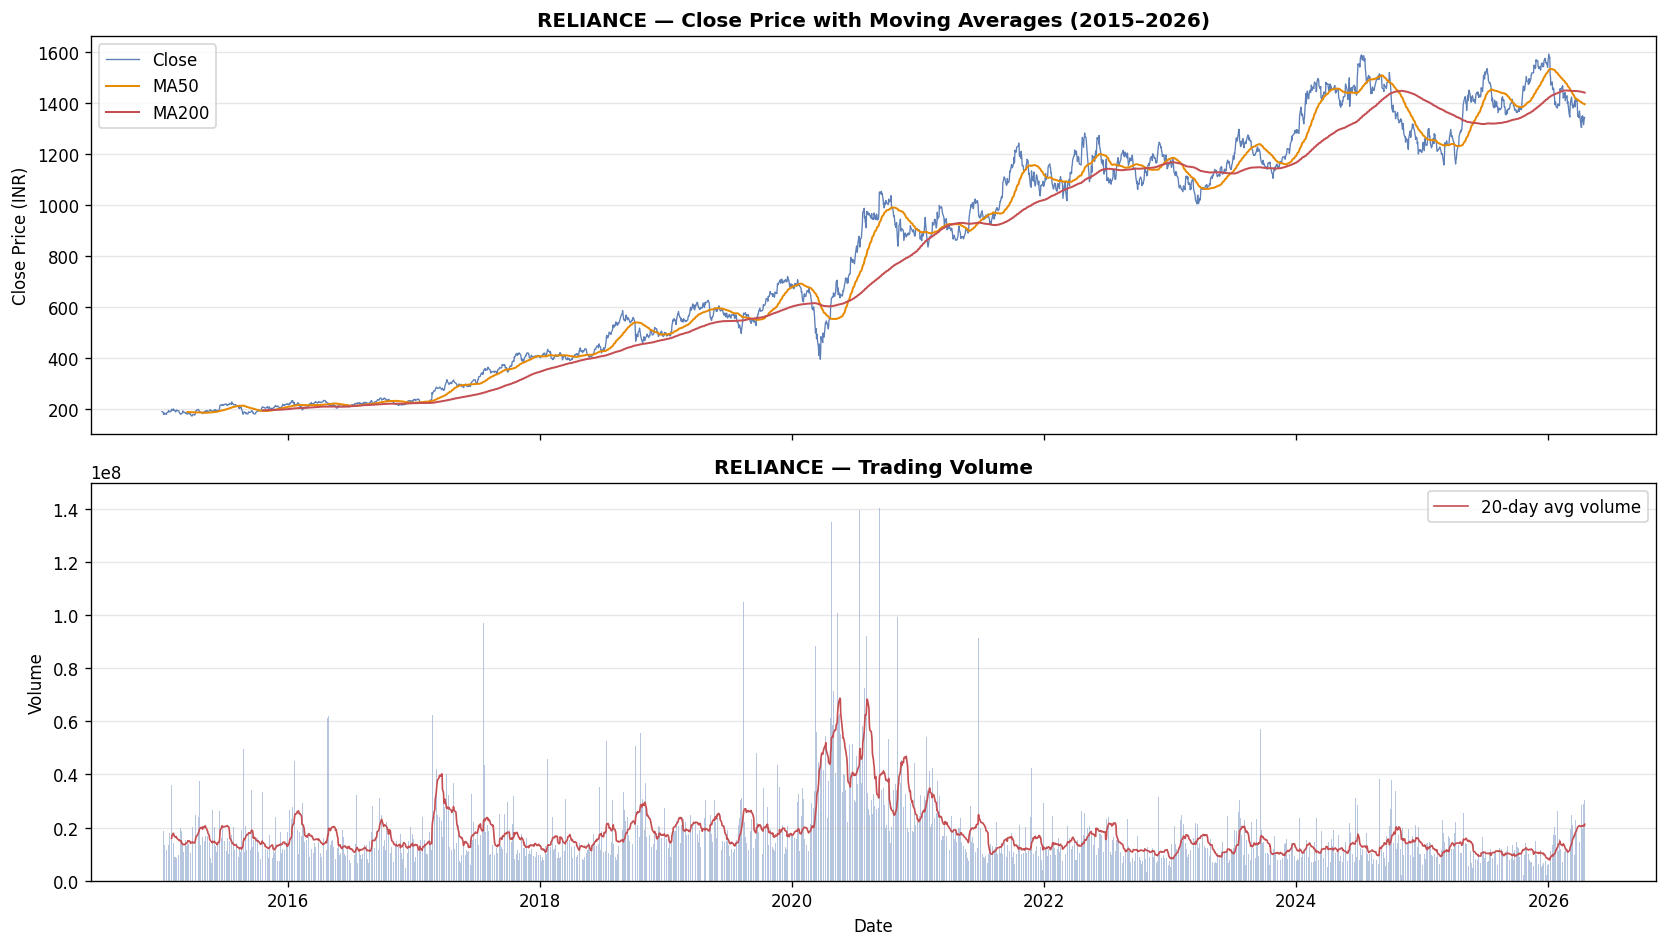

In [5]:
df = dfs['RELIANCE']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price with 50-day and 200-day MA
ma50  = df['Close'].rolling(50).mean()
ma200 = df['Close'].rolling(200).mean()
axes[0].plot(df['Date'], df['Close'],  color='#4C72B0', linewidth=0.8,  label='Close', alpha=0.9)
axes[0].plot(df['Date'], ma50,         color='#E88A00', linewidth=1.2,  label='MA50')
axes[0].plot(df['Date'], ma200,        color='#C44E52', linewidth=1.2,  label='MA200')
axes[0].set_title('RELIANCE — Close Price with Moving Averages (2015–2026)', fontweight='bold')
axes[0].set_ylabel('Close Price (INR)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Volume as bar chart
axes[1].bar(df['Date'], df['Volume'], color='#4C72B0', alpha=0.4, width=1)
vol_ma20 = df['Volume'].rolling(20).mean()
axes[1].plot(df['Date'], vol_ma20, color='#C44E52', linewidth=1, label='20-day avg volume')
axes[1].set_title('RELIANCE — Trading Volume', fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_reliance_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 6 — Daily Returns Distribution

Daily returns are computed as `(Close[t] - Close[t-1]) / Close[t-1]`. A normal distribution overlay is shown for comparison. Stock returns typically exhibit fat tails (leptokurtosis) — extreme moves occur more frequently than a normal distribution would predict.

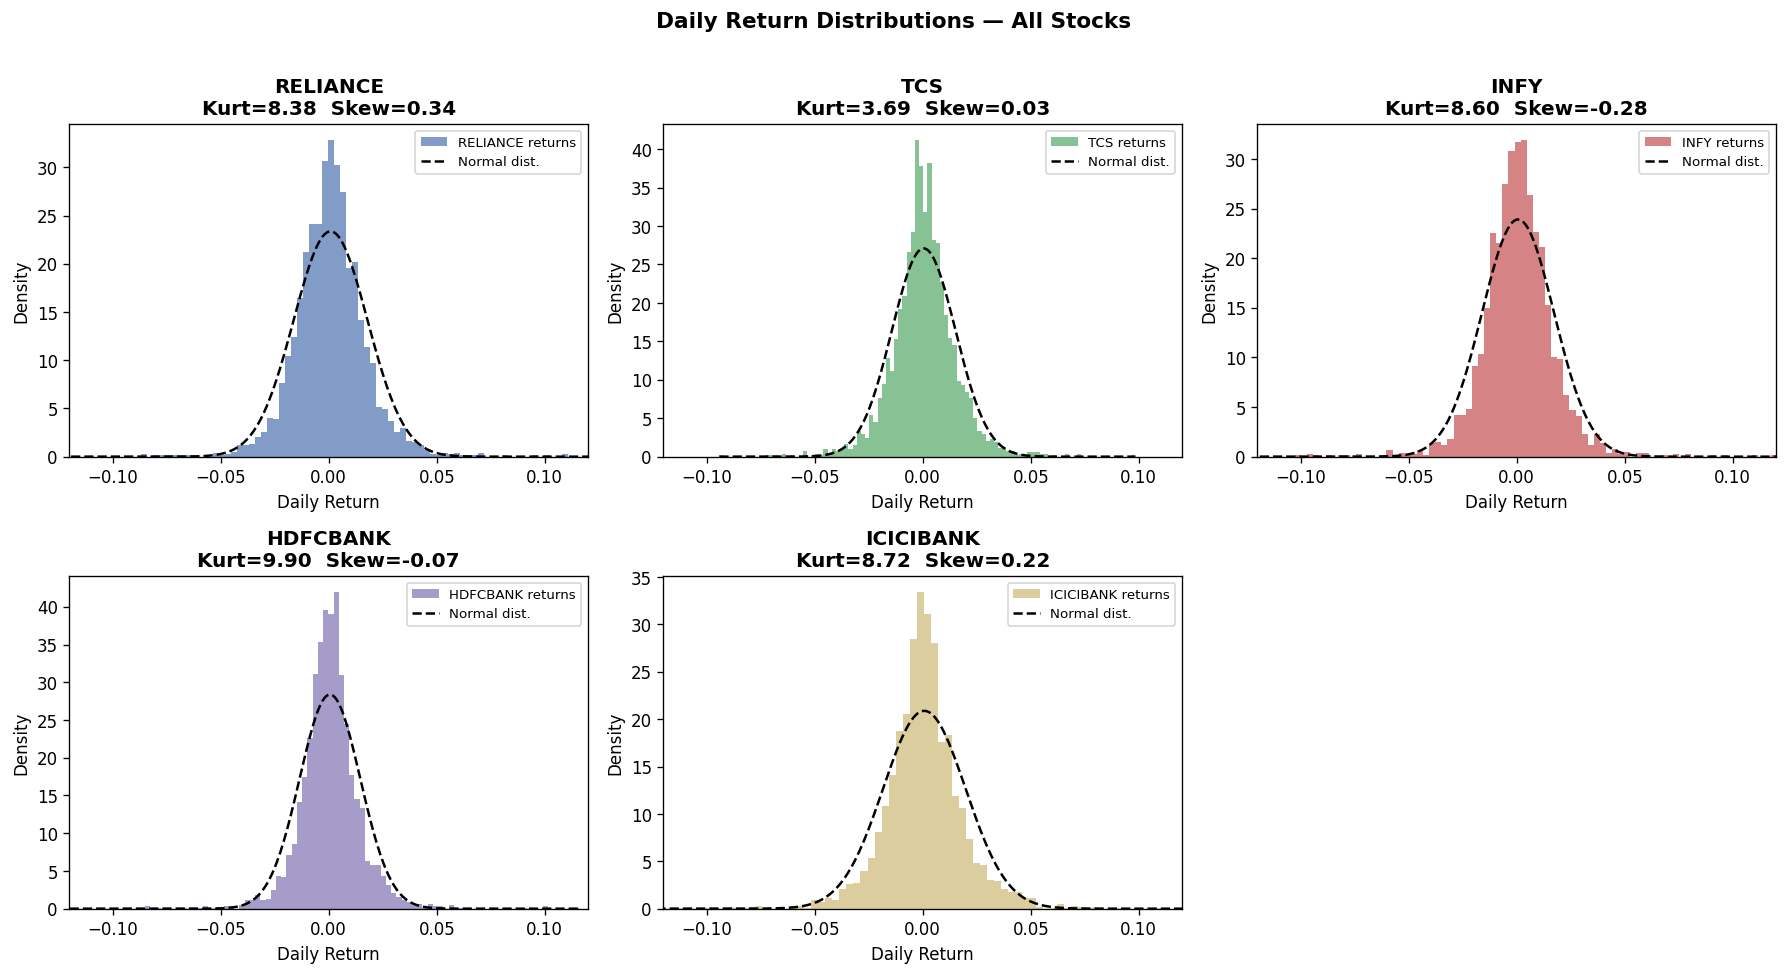

=== Return Statistics ===
RELIANCE      mean=0.085%  std=1.708%  min=-13.15%  max=14.72%  kurt=8.38
TCS           mean=0.045%  std=1.473%  min=-9.41%  max=9.85%  kurt=3.69
INFY          mean=0.060%  std=1.668%  min=-16.19%  max=12.03%  kurt=8.60
HDFCBANK      mean=0.057%  std=1.406%  min=-12.61%  max=11.60%  kurt=9.90
ICICIBANK     mean=0.073%  std=1.911%  min=-17.85%  max=14.69%  kurt=8.72


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (stock, color) in enumerate(zip(STOCKS, COLORS)):
    df      = dfs[stock].copy()
    returns = df['Close'].pct_change().dropna()

    axes[i].hist(returns, bins=100, color=color, alpha=0.7,
                 density=True, label=f'{stock} returns')

    # Normal distribution overlay
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 300)
    axes[i].plot(x, stats.norm.pdf(x, mu, sigma),
                 color='black', linewidth=1.5, linestyle='--', label='Normal dist.')

    kurt  = returns.kurt()
    skew  = returns.skew()
    axes[i].set_title(f'{stock}\nKurt={kurt:.2f}  Skew={skew:.2f}', fontweight='bold')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(-0.12, 0.12)

axes[5].axis('off')  # hide unused 6th subplot

plt.suptitle('Daily Return Distributions — All Stocks', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stock_datasets/eda_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Return Statistics ===')
for stock in STOCKS:
    r = dfs[stock]['Close'].pct_change().dropna()
    print(f'{stock:12s}  mean={r.mean()*100:.3f}%  std={r.std()*100:.3f}%  min={r.min()*100:.2f}%  max={r.max()*100:.2f}%  kurt={r.kurt():.2f}')

## STEP 7 — Inter-Stock Correlation Analysis

Pearson correlation of daily returns between all 5 stocks. High correlation means the stocks move together — useful context for understanding whether RELIANCE movements are driven by sector-wide factors.

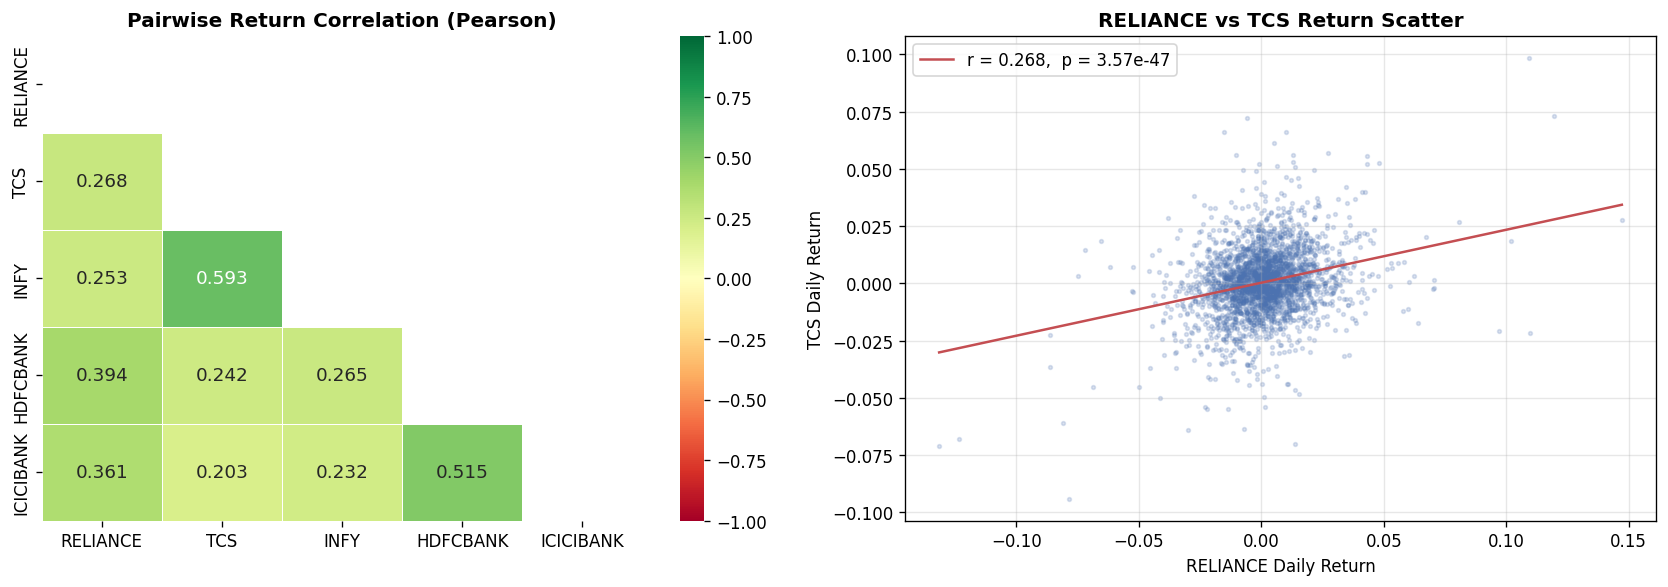

=== Correlation Matrix ===
           RELIANCE    TCS   INFY  HDFCBANK  ICICIBANK
RELIANCE      1.000  0.268  0.253     0.394      0.361
TCS           0.268  1.000  0.593     0.242      0.203
INFY          0.253  0.593  1.000     0.265      0.232
HDFCBANK      0.394  0.242  0.265     1.000      0.515
ICICIBANK     0.361  0.203  0.232     0.515      1.000


In [7]:
# Build returns DataFrame
returns_df = pd.DataFrame({
    stock: dfs[stock].set_index('Date')['Close'].pct_change()
    for stock in STOCKS
}).dropna()

corr = returns_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            mask=mask, annot_kws={'size': 11})
axes[0].set_title('Pairwise Return Correlation (Pearson)', fontweight='bold')

# Scatter: RELIANCE vs TCS
axes[1].scatter(returns_df['RELIANCE'], returns_df['TCS'],
                alpha=0.2, s=5, color='#4C72B0')
m, b, r, p, _ = stats.linregress(returns_df['RELIANCE'], returns_df['TCS'])
x_line = np.linspace(returns_df['RELIANCE'].min(), returns_df['RELIANCE'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='#C44E52', linewidth=1.5,
             label=f'r = {r:.3f},  p = {p:.2e}')
axes[1].set_xlabel('RELIANCE Daily Return')
axes[1].set_ylabel('TCS Daily Return')
axes[1].set_title('RELIANCE vs TCS Return Scatter', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Correlation Matrix ===')
print(corr.round(3).to_string())

## STEP 8 — RELIANCE: Bollinger Bands

Bollinger Bands consist of a 20-day simple moving average (middle band) with upper and lower bands at ±2 standard deviations. Price touching the upper band signals overbought conditions; touching the lower band signals oversold conditions.

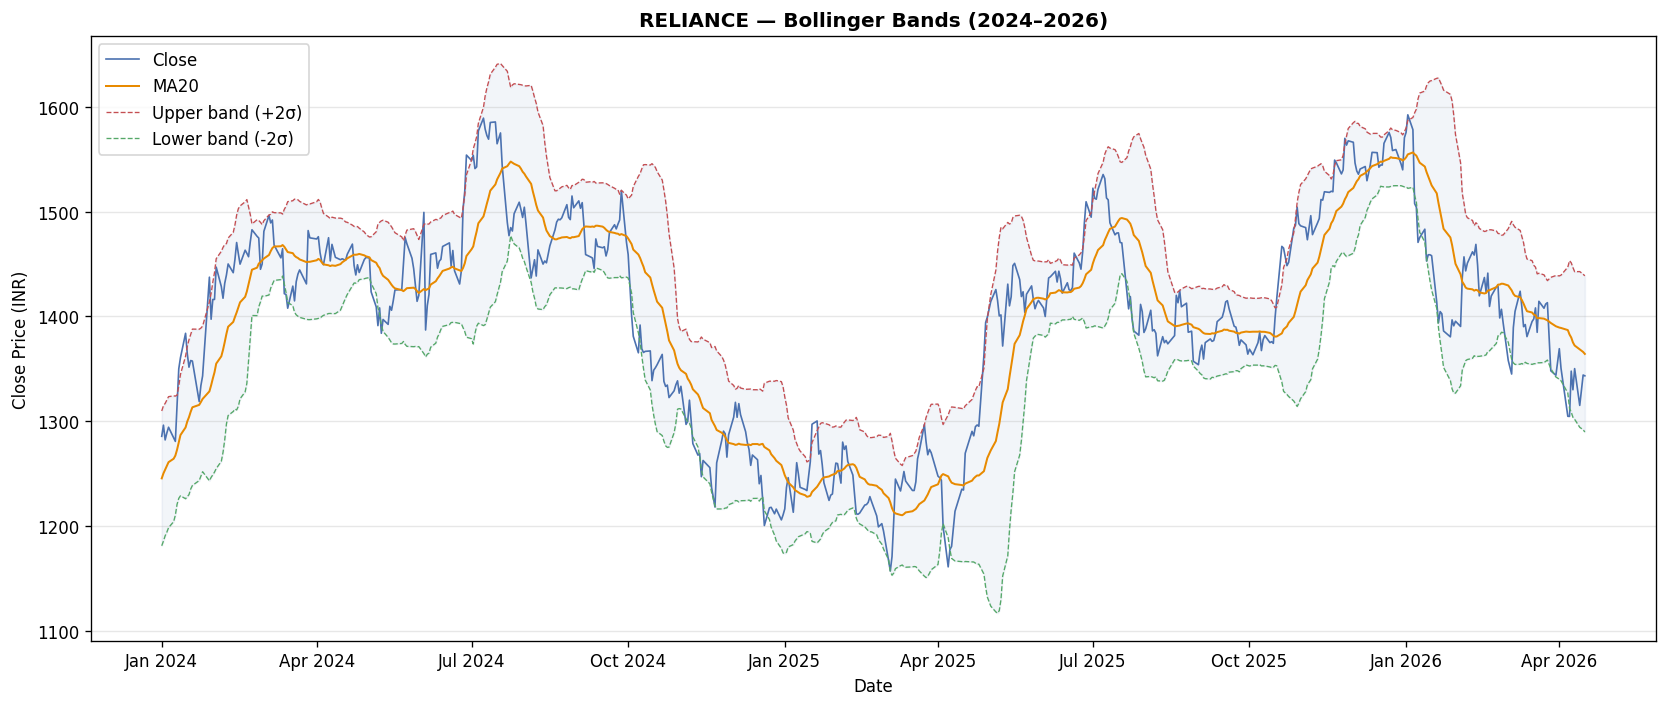

In [8]:
df = dfs['RELIANCE'].copy()

window = 20
df['MA20']  = df['Close'].rolling(window).mean()
df['STD20'] = df['Close'].rolling(window).std()
df['Upper'] = df['MA20'] + 2 * df['STD20']
df['Lower'] = df['MA20'] - 2 * df['STD20']
df = df.dropna()

# Plot last 2 years for clarity
df_plot = df[df['Date'] >= '2024-01-01']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_plot['Date'], df_plot['Close'],  color='#4C72B0', linewidth=1,   label='Close')
ax.plot(df_plot['Date'], df_plot['MA20'],   color='#E88A00', linewidth=1.2, label='MA20')
ax.plot(df_plot['Date'], df_plot['Upper'],  color='#C44E52', linewidth=0.8,
        linestyle='--', label='Upper band (+2σ)')
ax.plot(df_plot['Date'], df_plot['Lower'],  color='#55A868', linewidth=0.8,
        linestyle='--', label='Lower band (-2σ)')
ax.fill_between(df_plot['Date'], df_plot['Upper'], df_plot['Lower'],
                alpha=0.07, color='#4C72B0')

ax.set_title('RELIANCE — Bollinger Bands (2024–2026)', fontweight='bold')
ax.set_ylabel('Close Price (INR)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_bollinger_bands.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 9 — RELIANCE: RSI Analysis (Wilder's Method)

The Relative Strength Index (RSI) measures the speed and magnitude of price changes. RSI > 70 indicates overbought territory (potential sell signal); RSI < 30 indicates oversold territory (potential buy signal). Calculated using Wilder's exponential moving average (alpha = 1/14).

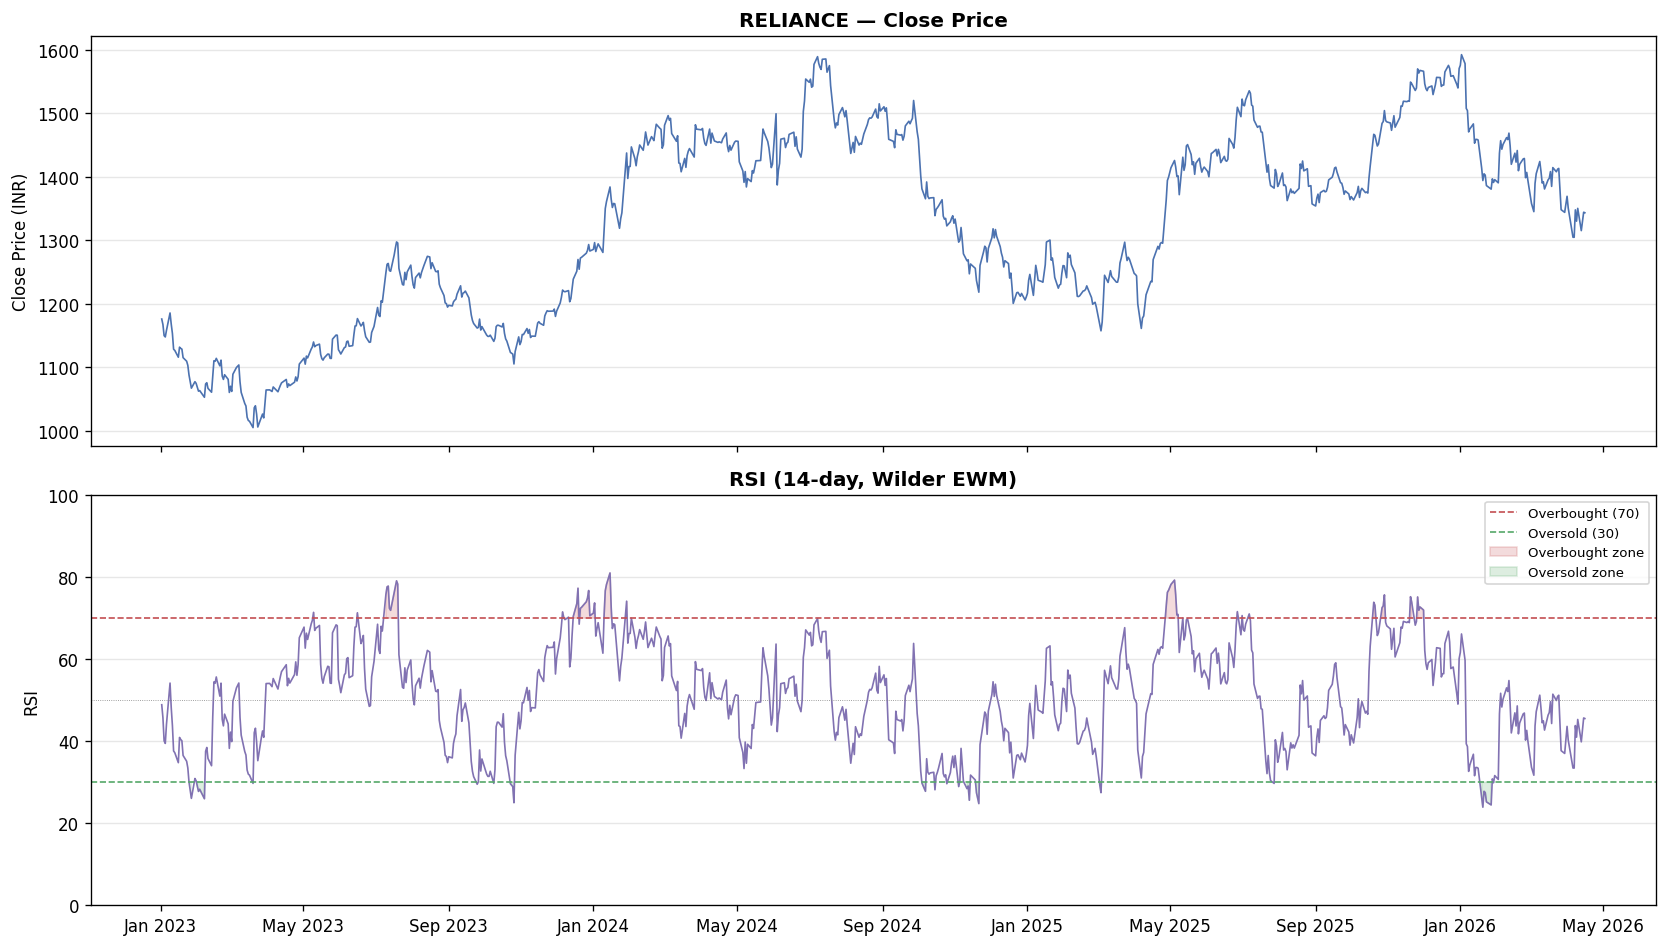

Days in overbought zone (RSI >= 70): 231 (8.3%)
Days in oversold   zone (RSI <= 30): 68   (2.5%)


In [9]:
df = dfs['RELIANCE'].copy()

delta    = df['Close'].diff()
gain     = delta.where(delta > 0, 0.0)
loss     = -delta.where(delta < 0, 0.0)
avg_gain = gain.ewm(com=13, min_periods=14).mean()
avg_loss = loss.ewm(com=13, min_periods=14).mean()
rs       = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))
df = df.dropna()

df_plot = df[df['Date'] >= '2023-01-01']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_plot['Date'], df_plot['Close'], color='#4C72B0', linewidth=1)
axes[0].set_title('RELIANCE — Close Price', fontweight='bold')
axes[0].set_ylabel('Close Price (INR)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(df_plot['Date'], df_plot['RSI'], color='#8172B2', linewidth=1)
axes[1].axhline(70, color='#C44E52', linewidth=1, linestyle='--', label='Overbought (70)')
axes[1].axhline(30, color='#55A868', linewidth=1, linestyle='--', label='Oversold (30)')
axes[1].axhline(50, color='gray',    linewidth=0.5, linestyle=':')
axes[1].fill_between(df_plot['Date'], df_plot['RSI'], 70,
                     where=(df_plot['RSI'] >= 70), alpha=0.2, color='#C44E52', label='Overbought zone')
axes[1].fill_between(df_plot['Date'], df_plot['RSI'], 30,
                     where=(df_plot['RSI'] <= 30), alpha=0.2, color='#55A868', label='Oversold zone')
axes[1].set_title('RSI (14-day, Wilder EWM)', fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_rsi.png', dpi=150, bbox_inches='tight')
plt.show()

overbought = (df['RSI'] >= 70).sum()
oversold   = (df['RSI'] <= 30).sum()
print(f'Days in overbought zone (RSI >= 70): {overbought} ({overbought/len(df)*100:.1f}%)')
print(f'Days in oversold   zone (RSI <= 30): {oversold}   ({oversold/len(df)*100:.1f}%)')

## STEP 10 — Volatility Analysis

Rolling 30-day annualised volatility (standard deviation of daily returns × √252). Volatility spikes typically correspond to market events — COVID crash (Mar 2020), Russia-Ukraine war (Feb 2022), US rate hike cycle (2022–2023).

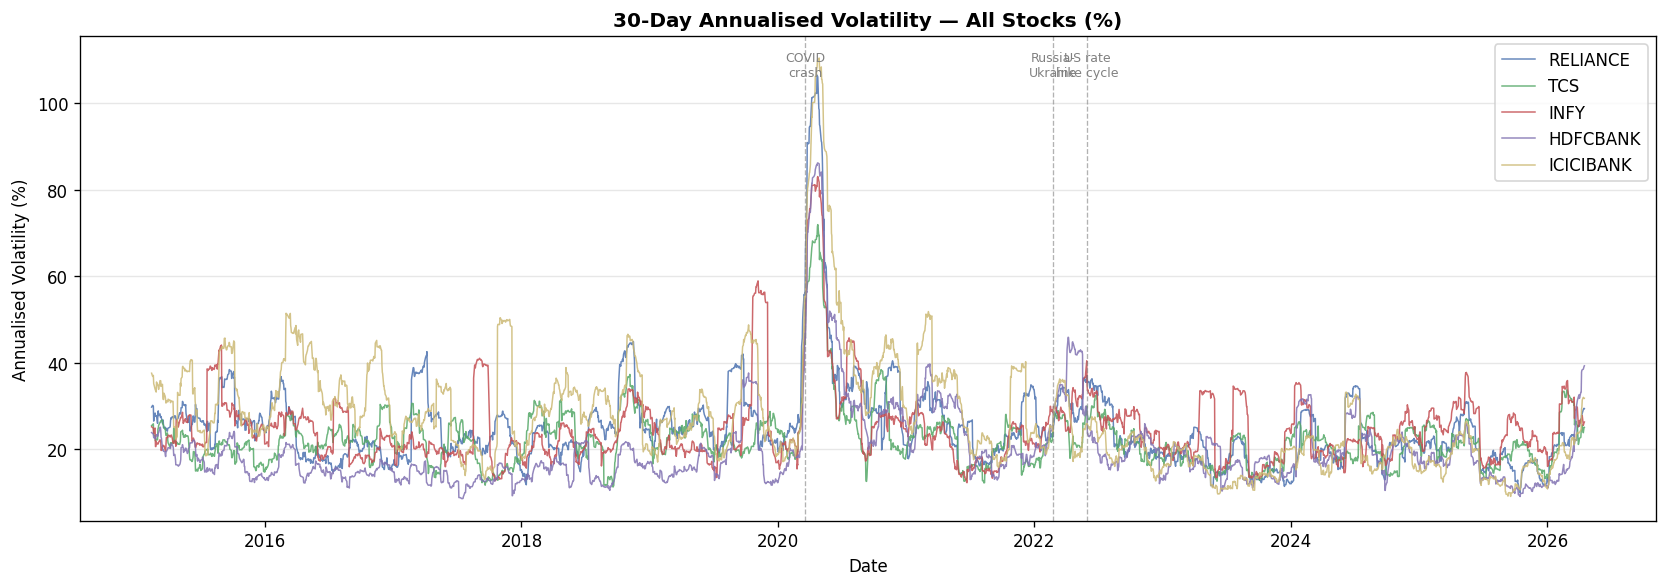

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

for stock, color in zip(STOCKS, COLORS):
    df      = dfs[stock].copy()
    returns = df['Close'].pct_change()
    vol30   = returns.rolling(30).std() * np.sqrt(252) * 100
    ax.plot(df['Date'], vol30, label=stock, color=color, linewidth=0.9, alpha=0.85)

# Annotate key events
events = {
    '2020-03-20': 'COVID\ncrash',
    '2022-02-24': 'Russia-\nUkraine',
    '2022-06-01': 'US rate\nhike cycle',
}
for date_str, label in events.items():
    ax.axvline(pd.Timestamp(date_str), color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.text(pd.Timestamp(date_str), ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 80,
            label, fontsize=7.5, ha='center', color='gray')

ax.set_title('30-Day Annualised Volatility — All Stocks (%)', fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 11 — Year-Wise Annual Returns

Annual return for each stock = `(year_end_close - year_start_close) / year_start_close × 100`.

=== Annual Returns (%) ===
      RELIANCE    TCS   INFY  HDFCBANK  ICICIBANK
Year                                             
2015     15.71  -2.77  14.72     14.52     -24.54
2016      7.80  -0.33  -6.51     11.70      -0.93
2017     71.11  16.64   7.16     57.45      38.17
2018     24.07  45.24  32.06     15.14      16.58
2019     35.87  17.63  13.52     19.44      48.51
2020     33.30  34.60  74.60     12.33      -0.32
2021     19.57  29.06  52.73      4.26      40.72
2022      6.31 -13.52 -18.84      8.39      17.20
2023      9.11  20.46   3.93      6.15      11.34
2024     -5.83   9.50  25.02      5.83      29.35
2025     29.10 -19.32 -11.65     12.70       5.42
2026    -14.74 -18.70 -19.06    -19.74       0.56


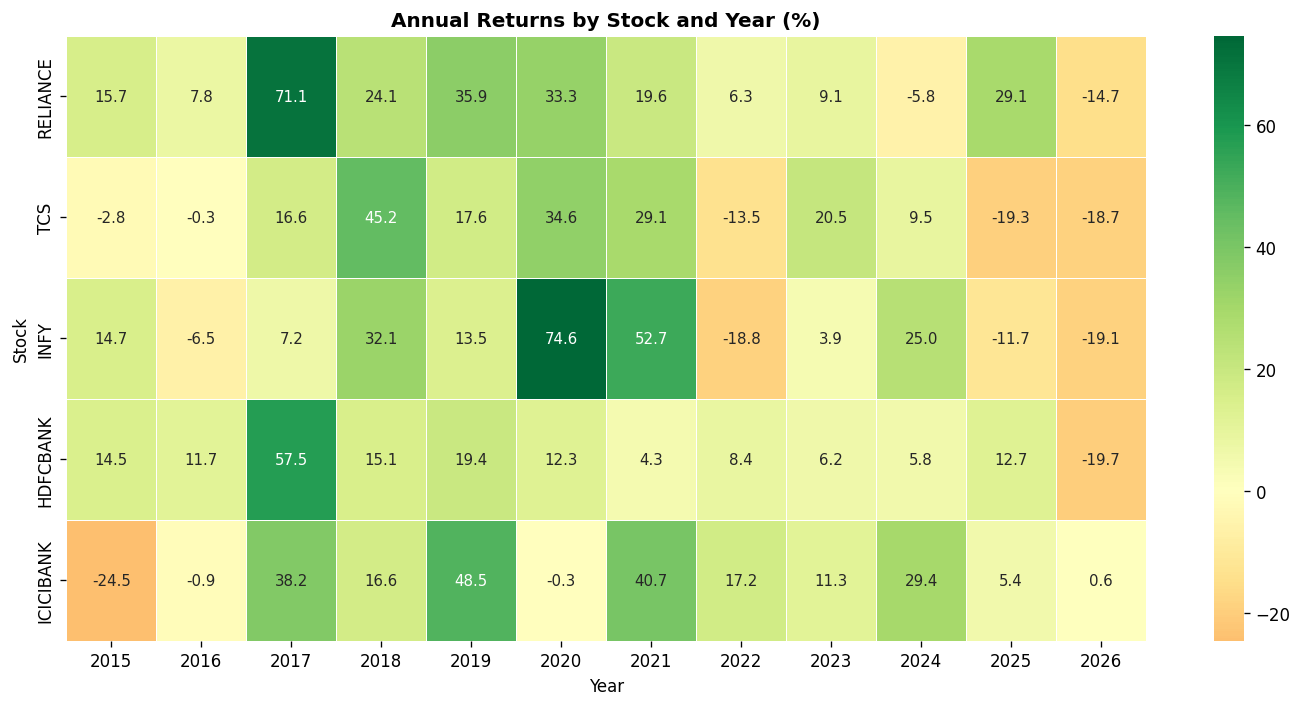

In [11]:
yearly_returns = {}
for stock in STOCKS:
    df = dfs[stock].copy()
    df['Year']  = df['Date'].dt.year
    yr = df.groupby('Year')['Close'].agg(['first', 'last'])
    yr['Return'] = (yr['last'] - yr['first']) / yr['first'] * 100
    yearly_returns[stock] = yr['Return']

yr_df = pd.DataFrame(yearly_returns).round(2)
print('=== Annual Returns (%) ===')
print(yr_df.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(yr_df.T, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Annual Returns by Stock and Year (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Stock')

plt.tight_layout()
plt.savefig('stock_datasets/eda_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 12 — RELIANCE: Autocorrelation (ACF)

Autocorrelation measures how much today's price is correlated with past prices. High autocorrelation at lag 1 justifies the use of lag features in the ML models. It also indicates that simpler models like Linear Regression with lag features may outperform complex models.

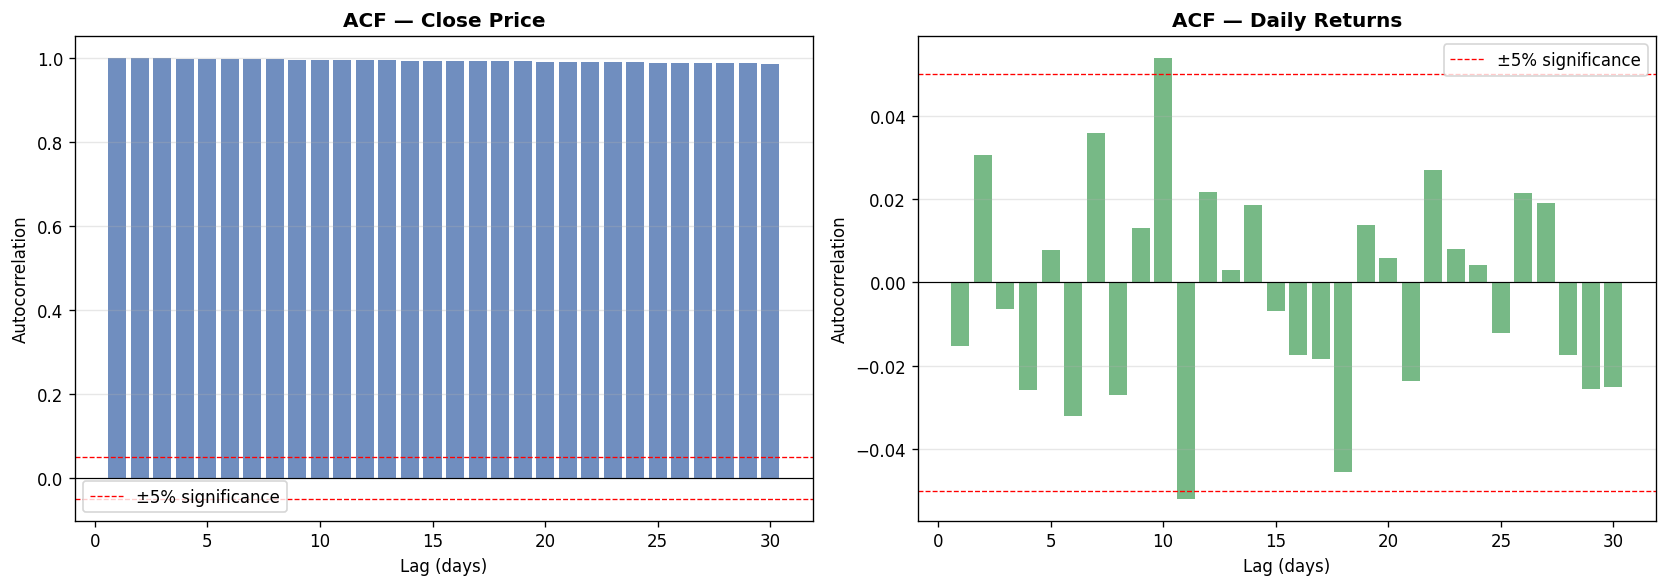

Lag-1 autocorrelation of Close price  : 0.9995
Lag-1 autocorrelation of Daily returns: -0.0153

High close-price autocorrelation justifies lag features in the ML models.


In [12]:
from pandas.plotting import autocorrelation_plot

df      = dfs['RELIANCE'].copy()
returns = df['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF of Close price
lags = range(1, 31)
acf_close   = [df['Close'].autocorr(lag=l)   for l in lags]
acf_returns = [returns.autocorr(lag=l)        for l in lags]

axes[0].bar(lags, acf_close, color='#4C72B0', alpha=0.8)
axes[0].axhline(0,    color='black', linewidth=0.7)
axes[0].axhline( 0.05, color='red', linewidth=0.8, linestyle='--', label='±5% significance')
axes[0].axhline(-0.05, color='red', linewidth=0.8, linestyle='--')
axes[0].set_title('ACF — Close Price', fontweight='bold')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(lags, acf_returns, color='#55A868', alpha=0.8)
axes[1].axhline(0,    color='black', linewidth=0.7)
axes[1].axhline( 0.05, color='red', linewidth=0.8, linestyle='--', label='±5% significance')
axes[1].axhline(-0.05, color='red', linewidth=0.8, linestyle='--')
axes[1].set_title('ACF — Daily Returns', fontweight='bold')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Autocorrelation')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Lag-1 autocorrelation of Close price  : {df["Close"].autocorr(1):.4f}')
print(f'Lag-1 autocorrelation of Daily returns: {returns.autocorr(1):.4f}')
print('\nHigh close-price autocorrelation justifies lag features in the ML models.')

## STEP 13 — RELIANCE: OHLC Candlestick (Recent 60 Days)

A candlestick chart shows open, high, low, and close for each trading day. Green candles = close above open (bullish); red candles = close below open (bearish).

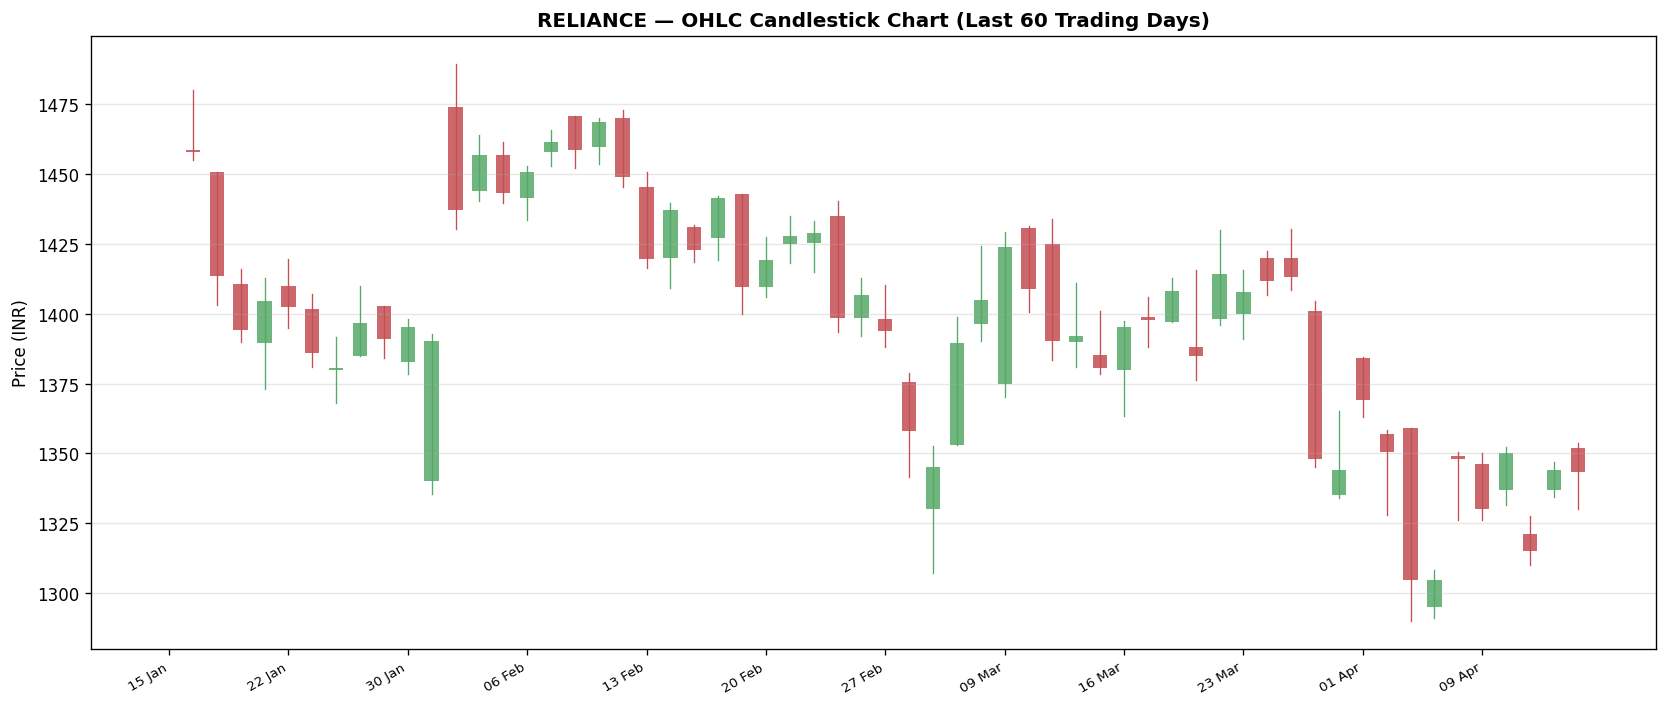

In [13]:
df      = dfs['RELIANCE'].copy()
df_plot = df.tail(60).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

for i, row in df_plot.iterrows():
    color  = '#55A868' if row['Close'] >= row['Open'] else '#C44E52'
    # Candle body
    ax.bar(i, abs(row['Close'] - row['Open']),
           bottom=min(row['Open'], row['Close']),
           color=color, width=0.6, alpha=0.85)
    # Wick
    ax.plot([i, i], [row['Low'], row['High']],
            color=color, linewidth=0.8)

# X-axis: show dates at intervals
tick_positions = range(0, len(df_plot), 5)
tick_labels    = [df_plot.loc[i, 'Date'].strftime('%d %b') for i in tick_positions]
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

ax.set_title('RELIANCE — OHLC Candlestick Chart (Last 60 Trading Days)', fontweight='bold')
ax.set_ylabel('Price (INR)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stock_datasets/eda_candlestick.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 14 — EDA Summary and Key Findings

This section summarises the most important observations from the EDA and their implications for model building.

In [14]:
df      = dfs['RELIANCE'].copy()
returns = df['Close'].pct_change().dropna()

print('=' * 65)
print('EDA SUMMARY — KEY FINDINGS')
print('=' * 65)

print('\n1. PRICE RANGE')
print(f'   RELIANCE: INR {df["Close"].min():.2f} – INR {df["Close"].max():.2f}')
print(f'   Total appreciation (2015–2026): {(df["Close"].iloc[-1]/df["Close"].iloc[0] - 1)*100:.1f}%')

print('\n2. RETURN CHARACTERISTICS')
print(f'   Mean daily return : {returns.mean()*100:.4f}%')
print(f'   Daily volatility  : {returns.std()*100:.4f}%')
print(f'   Annualised vol    : {returns.std()*np.sqrt(252)*100:.2f}%')
print(f'   Skewness          : {returns.skew():.4f}  (negative = left tail heavier)')
print(f'   Kurtosis          : {returns.kurt():.4f}  (> 0 = fat tails)')

print('\n3. AUTOCORRELATION')
print(f'   Lag-1 ACF of Close    : {df["Close"].autocorr(1):.4f}')
print(f'   -> Very high: justifies lag features and Linear Regression')
print(f'   Lag-1 ACF of Returns  : {returns.autocorr(1):.4f}')
print(f'   -> Near zero: returns are almost unpredictable (efficient market)')

print('\n4. RSI STATISTICS')
delta    = df['Close'].diff()
gain     = delta.where(delta > 0, 0.0)
loss     = -delta.where(delta < 0, 0.0)
rs       = gain.ewm(com=13,min_periods=14).mean() / loss.ewm(com=13,min_periods=14).mean()
df['RSI'] = 100 - (100 / (1 + rs))
print(f'   Overbought days (RSI >= 70): {(df["RSI"]>=70).sum()}')
print(f'   Oversold   days (RSI <= 30): {(df["RSI"]<=30).sum()}')

print('\n5. IMPLICATIONS FOR MODEL BUILDING')
print('   - High price autocorrelation -> lag features are critical')
print('   - Fat-tailed returns -> tree models may struggle at extremes')
print('   - LSTM suited for non-linear temporal dependencies')
print('   - Linear Regression + lag features expected to perform well')
print('   - Scaling required: Volume magnitude differs from price features')
print('=' * 65)

EDA SUMMARY — KEY FINDINGS

1. PRICE RANGE
   RELIANCE: INR 173.49 – INR 1592.30
   Total appreciation (2015–2026): 607.0%

2. RETURN CHARACTERISTICS
   Mean daily return : 0.0848%
   Daily volatility  : 1.7075%
   Annualised vol    : 27.11%
   Skewness          : 0.3359  (negative = left tail heavier)
   Kurtosis          : 8.3783  (> 0 = fat tails)

3. AUTOCORRELATION
   Lag-1 ACF of Close    : 0.9995
   -> Very high: justifies lag features and Linear Regression
   Lag-1 ACF of Returns  : -0.0153
   -> Near zero: returns are almost unpredictable (efficient market)

4. RSI STATISTICS
   Overbought days (RSI >= 70): 231
   Oversold   days (RSI <= 30): 68

5. IMPLICATIONS FOR MODEL BUILDING
   - High price autocorrelation -> lag features are critical
   - Fat-tailed returns -> tree models may struggle at extremes
   - LSTM suited for non-linear temporal dependencies
   - Linear Regression + lag features expected to perform well
   - Scaling required: Volume magnitude differs from price 